In [1]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split

In [2]:
df = sns.load_dataset('iris')

In [3]:
# perceptron (no hidden layers) then ANN (hidden layers)

In [4]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [5]:
print(df.shape)
df.info()

(150, 5)
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


In [6]:
df.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(1)

In [8]:
df = df.drop_duplicates()

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
encoder = LabelEncoder()

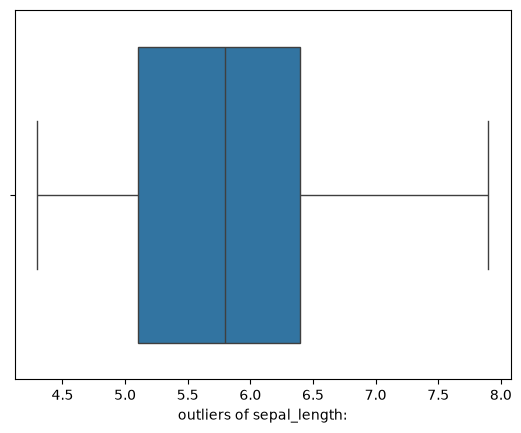

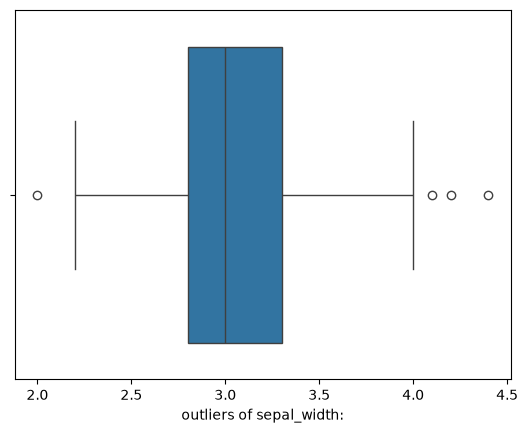

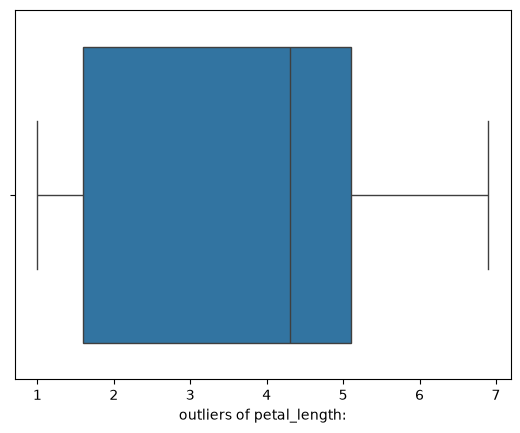

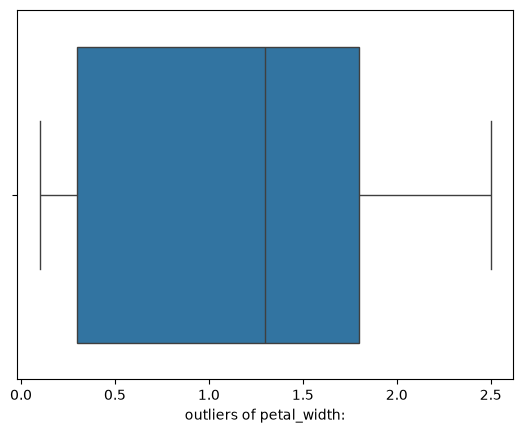

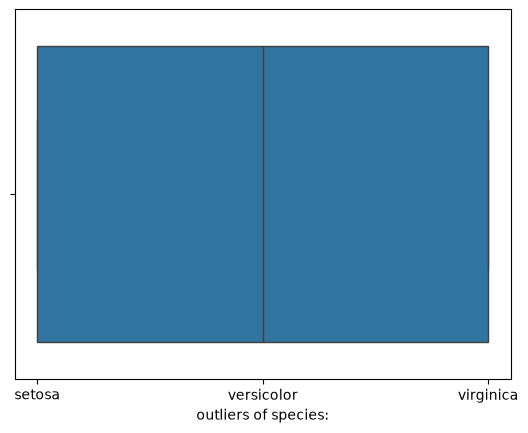

In [11]:
columns = df[['sepal_length', 'sepal_width', 'petal_length',
              'petal_width', 'species']]
for col in columns:
    plt.Figure(figsize=(18,6))
    sns.boxplot(x = df[col])
    plt.xlabel(f'outliers of {col}:')
    plt.show()

In [12]:
df['sepal_width'] = np.log1p(df['sepal_width'])

In [13]:
#done with data science steps, now with DL

In [14]:
x = df[['sepal_length', 'sepal_width', 'petal_length',
              'petal_width']]
y = df[['species']]
y = encoder.fit_transform(y) #encoding it now cause it needed to be defined

c:\Users\korej\anaconda3\envs\ml\Lib\site-packages\sklearn\preprocessing\_label.py:120: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [15]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
weight = 2 * np.random.random((4,1))-1

In [16]:
#create the model from scratch with layers, no hidden one cus perceptron
perceptron = models.Sequential([
    layers.Input(shape=(4,)),
    layers.Dense(units=3, activation='softmax')
])

In [17]:
#create -> compile the fresh model
perceptron.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# val split isn't necessary to run but it creates a third split of training data to avoid overfitting
p_lossCurve = perceptron.fit(x_train, y_train, epochs=100, batch_size=8, validation_split=0.2)
predict = perceptron.predict(x_test)

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.3579 - loss: 4.5515 - val_accuracy: 0.2917 - val_loss: 4.8735
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3263 - loss: 2.4917 - val_accuracy: 0.2917 - val_loss: 2.8550
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3895 - loss: 1.5447 - val_accuracy: 0.3750 - val_loss: 1.5140
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3263 - loss: 1.1798 - val_accuracy: 0.2500 - val_loss: 1.1626
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2737 - loss: 1.0847 - val_accuracy: 0.4167 - val_loss: 1.1347
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4842 - loss: 1.0280 - val_accuracy: 0.2917 - val_loss: 1.0353
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5579 - loss: 0.9886 - val_accuracy: 0.3750 - val_loss: 0.9896
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6632 - loss: 0.9268 - val_accuracy: 0.3333 - 

In [19]:
# means show the first five rows, low accuracy at the start, so many mistakes
print("\nPredictions sample:\n", predict[:5])


Predictions sample:
 [[0.04422415 0.6059638  0.34981203]
 [0.93065184 0.06625227 0.003096  ]
 [0.00136425 0.34403235 0.6546033 ]
 [0.03039968 0.5534266  0.41617373]
 [0.05637017 0.58514196 0.3584879 ]]


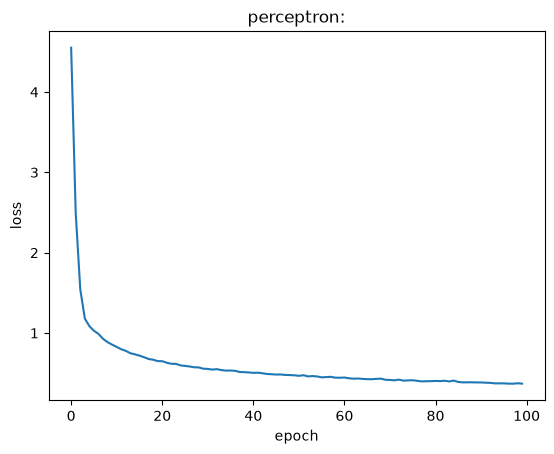

In [20]:
plt.Figure(figsize=(18,6))
plt.plot(p_lossCurve.history['loss'])
plt.title('perceptron:')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.show()

In [21]:
#now for ANN (Arificial neural networks), means at least one hidden layer

In [22]:
Ann = models.Sequential([
    layers.Input(shape=(4,)),
    layers.Dense(units=8, activation='relu'),
    layers.Dense(units=3,  activation='softmax')
])

In [23]:
Ann.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [24]:
Ann_curve= Ann.fit(x_train, y_train, epochs=100, batch_size=8, validation_split=0.2)
predict = Ann.predict(x_test)

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.2526 - loss: 1.4201 - val_accuracy: 0.5000 - val_loss: 0.9926
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3895 - loss: 0.9853 - val_accuracy: 0.5000 - val_loss: 1.0567
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6632 - loss: 0.9551 - val_accuracy: 0.2083 - val_loss: 0.9368
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5053 - loss: 0.9028 - val_accuracy: 0.5000 - val_loss: 0.9471
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6211 - loss: 0.8557 - val_accuracy: 0.5000 - val_loss: 0.9205
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5895 - loss: 0.8196 - val_accuracy: 0.5000 - val_loss: 0.8918
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6000 - loss: 0.8018 - val_accuracy: 0.5000 - val_loss: 0.8693
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6526 - loss: 0.7559 - val_accuracy: 0.5000 - 

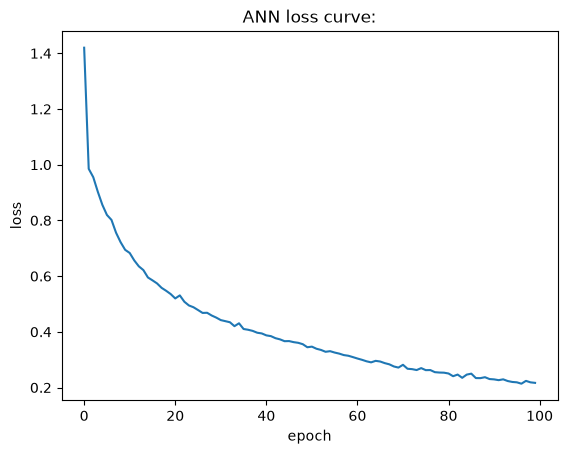

In [25]:
plt.Figure(figsize=(18,6))
plt.plot(Ann_curve.history['loss'])
plt.title('ANN loss curve:')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.show()